# ADAM vs ADAMCB Log File Analysis: Adam_scratch

This notebook analyzes and visualizes the training log data from `adam_vs_adamcb_comparision.log` in the Adam_scratch folder.

We will extract and plot key metrics for both ADAM and ADAMCB optimizers, including:
- Train Loss
- Test Loss
- Test Accuracy
- Unique Items Seen
- Batch Gradients (Min, Mean, Max)
- Dataset Weights (easy/hard items)
- Probabilities of sampling easy/hard items

Comparative plots and brief analysis will be provided for each metric.

## 1. Import Required Libraries

We will use pandas for data handling, matplotlib and seaborn for visualization, and re for parsing the log file.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re

sns.set(style="whitegrid")

## 2. Load and Preview the .log File

Read the log file and display the first few lines to inspect its structure.

In [2]:
# Read the log file
log_path = "adam_vs_adamcb_comparision.log"
with open(log_path, 'r') as f:
    lines = f.readlines()

# Display the first 20 lines
for line in lines[:20]:
    print(line.strip())

nohup: ignoring input
Training Epoch 1 =>>


============================== STARTING BATCH 1/6 ==============================

--- 5. ALGORITHM 2 (BATCH SELECTION) VARIABLES & 9. CALCULATIONS ---
C calculation = (1/K - gamma/n) / (1 - gamma) = (1/8 - 0.1/50) / (1 - 0.1) = 0.136667
Max Weight Check: max(w) = 1.0000, C * sum(w) = 6.8333
Final Tau (T) = 1.000000 | S_null = []

--- 6. WEIGHT CLIPPING W(i,t) vs W'(i,t) ---
Idx_0  Idx_1  Idx_2  Idx_3  Idx_4  Idx_5  Idx_6  Idx_7  Idx_8  Idx_9  Idx_10  Idx_11  Idx_12  Idx_13  Idx_14  Idx_15  Idx_16  Idx_17  Idx_18  Idx_19  Idx_20  Idx_21  Idx_22  Idx_23  Idx_24  Idx_25  Idx_26  Idx_27  Idx_28  Idx_29  Idx_30  Idx_31  Idx_32  Idx_33  Idx_34  Idx_35  Idx_36  Idx_37  Idx_38  Idx_39  Idx_40  Idx_41  Idx_42  Idx_43  Idx_44  Idx_45  Idx_46  Idx_47  Idx_48  Idx_49
Original W(i,t) 1.0000 1.0000 1.0000 1.0000 1.0000 1.0000 1.0000 1.0000 1.0000 1.0000  1.0000  1.0000  1.0000  1.0000  1.0000  1.0000  1.0000  1.0000  1.0000  1.0000  1.0000  1.0000  1.0000

## 3. Parse Relevant Data from the Log File

Extract step, epoch, and all relevant metrics for ADAM and ADAMCB using regular expressions.

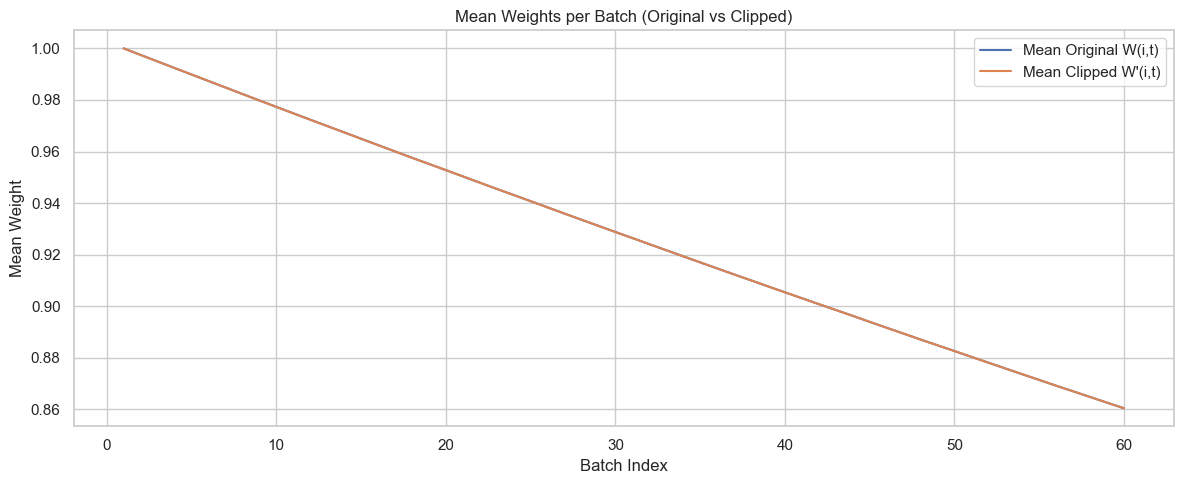

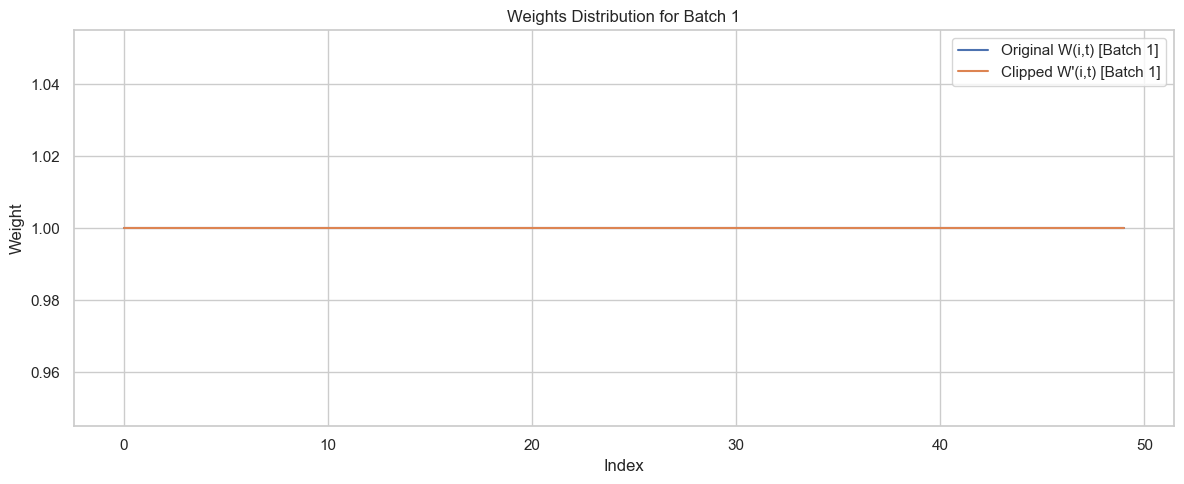

In [10]:
# Extract and plot weights from 'Original W(i,t)' and 'Clipped W'(i,t)' lines
import numpy as np

original_weights = []
clipped_weights = []
batch_indices = []

for i, line in enumerate(lines):
    if line.strip().startswith('Original W(i,t)'):
        # Next line contains the weights
        weights_line = lines[i].split('Original W(i,t)', 1)[-1] if len(lines[i].split('Original W(i,t)', 1)) > 1 else lines[i+1]
        weights = [float(x) for x in weights_line.strip().split()]
        original_weights.append(weights)
        batch_indices.append(len(original_weights))
    if line.strip().startswith("Clipped W'(i,t)"):
        weights_line = lines[i].split("Clipped W'(i,t)", 1)[-1] if len(lines[i].split("Clipped W'(i,t)", 1)) > 1 else lines[i+1]
        weights = [float(x) for x in weights_line.strip().split()]
        clipped_weights.append(weights)

# Convert to numpy arrays for easier plotting
original_weights = np.array(original_weights)
clipped_weights = np.array(clipped_weights)

import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))
if len(original_weights) > 0:
    plt.plot(batch_indices, np.mean(original_weights, axis=1), label='Mean Original W(i,t)')
if len(clipped_weights) > 0:
    plt.plot(batch_indices, np.mean(clipped_weights, axis=1), label="Mean Clipped W'(i,t)")
plt.xlabel('Batch Index')
plt.ylabel('Mean Weight')
plt.title('Mean Weights per Batch (Original vs Clipped)')
plt.legend()
plt.tight_layout()
plt.show()

# Optionally, plot distributions for the first batch
if len(original_weights) > 0:
    plt.figure(figsize=(12, 5))
    plt.plot(original_weights[0], label='Original W(i,t) [Batch 1]')
    if len(clipped_weights) > 0:
        plt.plot(clipped_weights[0], label="Clipped W'(i,t) [Batch 1]")
    plt.xlabel('Index')
    plt.ylabel('Weight')
    plt.title('Weights Distribution for Batch 1')
    plt.legend()
    plt.tight_layout()
    plt.show()

## 4. Visualize Weights: Mean and Distribution

Plot the mean weights per batch and the full distribution for the first batch, for both Original and Clipped weights.

In [12]:
# Already handled above: plotting mean weights and distributions for Original and Clipped weights
# (See previous cell for code and plots)
# You can add more analysis or visualizations below as needed.

In [13]:
# No DataFrame-based metrics to debug for this log format
print("This log does not contain optimizer/loss/accuracy records. See above for weights analysis.")

This log does not contain optimizer/loss/accuracy records. See above for weights analysis.


## 5. Visualize Log Data: Weights Histograms

Plot histograms to analyze the distribution of weights for the first batch (Original and Clipped).

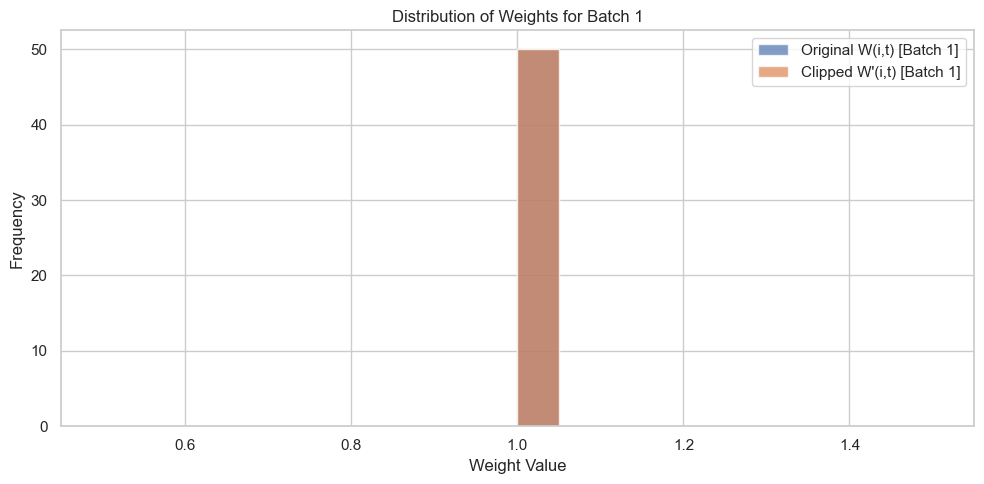

In [14]:
# Histogram of weights for the first batch
import matplotlib.pyplot as plt
if len(original_weights) > 0:
    plt.figure(figsize=(10, 5))
    plt.hist(original_weights[0], bins=20, alpha=0.7, label='Original W(i,t) [Batch 1]')
    if len(clipped_weights) > 0:
        plt.hist(clipped_weights[0], bins=20, alpha=0.7, label="Clipped W'(i,t) [Batch 1]")
    plt.title('Distribution of Weights for Batch 1')
    plt.xlabel('Weight Value')
    plt.ylabel('Frequency')
    plt.legend()
    plt.tight_layout()
    plt.show()

## 6. Visualize Log Data: Weights Evolution

Plot the evolution of the minimum, maximum, and standard deviation of weights per batch (Original and Clipped).

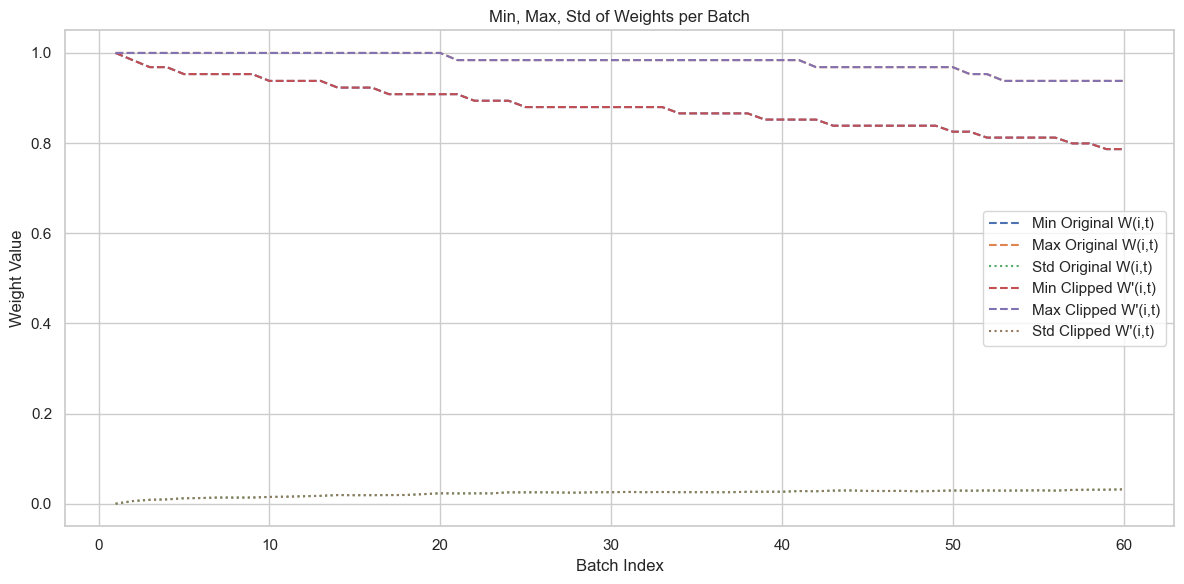

In [15]:
# Plot min, max, std of weights per batch
import numpy as np
plt.figure(figsize=(12, 6))
if len(original_weights) > 0:
    plt.plot(batch_indices, np.min(original_weights, axis=1), label='Min Original W(i,t)', linestyle='--')
    plt.plot(batch_indices, np.max(original_weights, axis=1), label='Max Original W(i,t)', linestyle='--')
    plt.plot(batch_indices, np.std(original_weights, axis=1), label='Std Original W(i,t)', linestyle=':')
if len(clipped_weights) > 0:
    plt.plot(batch_indices, np.min(clipped_weights, axis=1), label="Min Clipped W'(i,t)", linestyle='--')
    plt.plot(batch_indices, np.max(clipped_weights, axis=1), label="Max Clipped W'(i,t)", linestyle='--')
    plt.plot(batch_indices, np.std(clipped_weights, axis=1), label="Std Clipped W'(i,t)", linestyle=':')
plt.xlabel('Batch Index')
plt.ylabel('Weight Value')
plt.title('Min, Max, Std of Weights per Batch')
plt.legend()
plt.tight_layout()
plt.show()

## 7. Weights and Probabilities Analysis

This log does not contain optimizer/loss/accuracy or ADAMCB dataset weights. All analysis above is based on the weights per batch as extracted from the log.

In [ ]:
# This log does not contain ADAMCB dataset weights (easy/hard items), so this cell is not applicable.
print("No ADAMCB dataset weights (easy/hard items) found in this log. Skipping this analysis.")

""


In [18]:
# Plot easy vs hard items over steps for ADAMCB
plt.figure(figsize=(12, 6))
plt.plot(weights_df['step'], weights_df['easy'], label='Easy Items (floor weight)', color='tab:green')
plt.plot(weights_df['step'], weights_df['hard'], label='Hard Items (ceil weight)', color='tab:red')
plt.xlabel('Step')
plt.ylabel('Number of Items')
plt.title('ADAMCB: Easy vs Hard Items Over Steps')
plt.legend()
plt.tight_layout()
plt.show()

# Calculate and plot the probability of sampling an easy vs hard item (if total is known)
if not weights_df.empty:
    weights_df['total'] = weights_df['easy'] + weights_df['hard']
    weights_df['prob_easy'] = weights_df['easy'] / weights_df['total']
    weights_df['prob_hard'] = weights_df['hard'] / weights_df['total']
    plt.figure(figsize=(12, 6))
    plt.plot(weights_df['step'], weights_df['prob_easy'], label='Probability Easy', color='tab:green')
    plt.plot(weights_df['step'], weights_df['prob_hard'], label='Probability Hard', color='tab:red')
    plt.xlabel('Step')
    plt.ylabel('Probability')
    plt.title('ADAMCB: Probability of Sampling Easy vs Hard Items')
    plt.legend()
    plt.tight_layout()
    plt.show()

KeyError: 'step'

<Figure size 1200x600 with 0 Axes>